# 3.3 — Optimised Regression Modelling (Bayesian HPO + Stacking)

This notebook follows the same **dataset × model** structure as `3.1` but replaces fixed hyperparameters  
with **Bayesian optimisation via Optuna** and adds a **StackingRegressor** ensemble.

Works with all three prepared datasets including the new **2.4** (feature-engineered):

| Dataset | Source notebook | Key additions |
|---|---|---|
| 2.1-Manual | 2.1 | Listwise deletion |
| 2.2-UMAP-MICE | 2.2 | MICE imputation, UMAP clustering |
| **2.4-FeatEng** | **2.4** | **Feature engineering + year-based split** |

Results are saved to `./models/3.3-all_results_cache.joblib` so they can be compared  
side-by-side with `3.1`'s `./models/all_results_cache.joblib` in Section 7.

## Outline

| # | Section |
|---|---|
| 1 | Imports & Global Setup |
| 2 | Pipeline Helpers |
| 3 | Load All Datasets |
| 4 | Bayesian HPO — Search Spaces & `tune_and_run()` |
| 5 | Individual Tuned Runs — one cell per model |
| 6 | Stacking Ensemble |
| 7 | Full Comparison (3.3 results + vs 3.1 baseline) |
| 8 | CV vs Test RMSE Gap — Overfitting Diagnostic |

## 1. Imports & Global Setup

In [1]:
import subprocess, sys

_packages = [
    'polars', 'scikit-learn', 'xgboost', 'shap',
    'joblib', 'matplotlib', 'seaborn', 'jinja2',
    'numpy', 'pandas', 'optuna',
]
for pkg in _packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])

print('All dependencies installed (including optuna).')

All dependencies installed (including optuna).


In [2]:
from pathlib import Path

import polars as pl
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import RepeatedKFold, KFold, cross_validate, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    from xgboost import XGBRegressor
    _xgb_available = True
except ImportError:
    _xgb_available = False

import matplotlib.pyplot as plt
import seaborn as sns

print(f'Libraries loaded. XGBoost available: {_xgb_available}')

c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded. XGBoost available: True


## 2. Pipeline Helpers

Refactored from 3.1: `build_preprocessor()` is extracted so Optuna can reuse it inside the objective  
without rebuilding the full pipeline each trial. The preprocessor is fitted **once** per `tune_and_run()` call,
and the tuned model is fitted on the pre-transformed arrays for speed.

In [3]:
_NUMERIC_DTYPES = {
    pl.Int8,  pl.Int16,  pl.Int32,  pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}
_STRING_DTYPES = {pl.Utf8, pl.String, pl.Categorical}


def build_preprocessor(numeric_cols: list, cat_cols: list) -> ColumnTransformer:
    """Build a ColumnTransformer with median imputation + scaling / one-hot."""
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    transformers = []
    if numeric_cols:
        transformers.append(('num', numeric_transformer, numeric_cols))
    if cat_cols:
        cat_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ])
        transformers.append(('cat', cat_transformer, cat_cols))
    if not transformers:
        raise ValueError('No numeric or categorical columns found.')
    return ColumnTransformer(transformers=transformers, remainder='drop')


def _align_test(test_df: pl.DataFrame, feature_cols: list, X_train: pl.DataFrame) -> pl.DataFrame:
    """Align test DataFrame columns to match training feature columns."""
    aligned = pl.DataFrame()
    for col in feature_cols:
        if col in test_df.columns:
            aligned = aligned.with_columns(test_df[col])
        else:
            null_s = pl.Series([None] * test_df.shape[0], dtype=X_train[col].dtype).alias(col)
            aligned = aligned.with_columns(null_s)
    return aligned.select(feature_cols)


def _get_feature_names(preprocessor: ColumnTransformer, numeric_cols: list, cat_cols: list) -> list:
    onehot_cols = []
    if cat_cols:
        enc = preprocessor.named_transformers_['cat'].named_steps['onehot']
        onehot_cols = enc.get_feature_names_out(cat_cols).tolist()
    return numeric_cols + onehot_cols


print('Pipeline helpers defined: build_preprocessor(), _align_test(), _get_feature_names()')

Pipeline helpers defined: build_preprocessor(), _align_test(), _get_feature_names()


In [4]:
def build_regression_pipeline(
    train_df: pl.DataFrame,
    test_df:  pl.DataFrame,
    target:   str,
    model,
    model_name:   str  = 'Model',
    drop_cols:    list = None,
    n_splits:     int  = 5,
    n_repeats:    int  = 3,
    random_state: int  = 42,
) -> dict:
    """Same as 3.1 — used for LinearRegression baseline only (no HPO)."""
    all_drop     = [c for c in ([target] + (drop_cols or [])) if c in train_df.columns]
    feature_cols = [c for c in train_df.columns if c not in all_drop]
    X_train = train_df.select(feature_cols)
    y_train = train_df[target].to_numpy()
    X_test  = _align_test(test_df, feature_cols, X_train)
    y_test  = test_df[target].to_numpy()

    numeric_cols = [c for c in X_train.columns if X_train[c].dtype in _NUMERIC_DTYPES]
    cat_cols     = [c for c in X_train.columns if X_train[c].dtype in _STRING_DTYPES]
    print(f'  Features : {len(numeric_cols)} numeric, {len(cat_cols)} categorical')

    preprocessor = build_preprocessor(numeric_cols, cat_cols)
    cv = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    scoring = { 'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2' }
    pipe = Pipeline([('pre', preprocessor), ('model', model)])

    cv_res  = cross_validate(pipe, X_train.to_pandas(), y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_mae  = float(-cv_res['test_MAE'].mean())
    cv_rmse = float(-cv_res['test_RMSE'].mean())
    cv_r2   = float(cv_res['test_R2'].mean())
    print(f'  CV  : MAE={cv_mae:.4f}  RMSE={cv_rmse:.4f}  R²={cv_r2:.4f}')

    pipeline_final = Pipeline([('pre', build_preprocessor(numeric_cols, cat_cols)), ('model', model)])
    pipeline_final.fit(X_train.to_pandas(), y_train)
    y_pred    = pipeline_final.predict(X_test.to_pandas())
    test_mae  = float(mean_absolute_error(y_test, y_pred))
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    test_r2   = float(r2_score(y_test, y_pred))
    print(f'  Test: MAE={test_mae:.4f}  RMSE={test_rmse:.4f}  R²={test_r2:.4f}')

    feature_names = _get_feature_names(pipeline_final.named_steps['pre'], numeric_cols, cat_cols)
    return {
        'model_name': model_name, 'pipeline': pipeline_final, 'best_params': {},
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test, 'y_pred': y_pred,
        'feature_names': feature_names, 'numeric_cols': numeric_cols, 'cat_cols': cat_cols,
        'cv_mae': cv_mae, 'cv_rmse': cv_rmse, 'cv_r2': cv_r2,
        'test_mae': test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2,
    }

print('build_regression_pipeline() defined.')

build_regression_pipeline() defined.


## 3. Load All Datasets

Datasets: **2.1-Manual**, **2.2-UMAP-MICE**, and **2.4-FeatEng** (run notebook 2.4 first).

In [5]:
DATASETS = {
    '2.1-Manual': {
        'train_path': './data/interim/2.1-train.parquet',
        'test_path':  './data/interim/2.1-test.parquet',
    },
    '2.2-UMAP-MICE': {
        'train_path': './data/interim/2.2-train.parquet',
        'test_path':  './data/interim/2.2-test.parquet',
    },
    '2.4-FeatEng': {
        'train_path': './data/interim/2.4-train.parquet',
        'test_path':  './data/interim/2.4-test.parquet',
    },
}

TARGET   = 'health_gain'
all_data = {}

for label, paths in DATASETS.items():
    train_path = Path(paths['train_path'])
    test_path  = Path(paths['test_path'])
    if not train_path.exists():
        print(f'SKIP {label} — {train_path} not found. Run the corresponding data prep notebook first.')
        continue
    train_pl  = pl.read_parquet(train_path)
    test_pl   = pl.read_parquet(test_path)
    drop_cols = ['OHS_Success'] if 'OHS_Success' in train_pl.columns else []
    all_data[label] = (train_pl, test_pl, drop_cols)
    print(f'{label:20s}  train={train_pl.shape}  test={test_pl.shape}  drop={drop_cols}')

print(f'\nTarget  : {TARGET}')
print(f'Loaded  : {list(all_data.keys())}')

# ── Cache for 3.3 results ─────────────────────────────────────────────────────
RESULTS_PATH_33 = Path('./models/3.3-all_results_cache.joblib')
RESULTS_PATH_33.parent.mkdir(parents=True, exist_ok=True)

if RESULTS_PATH_33.exists():
    all_results_33 = joblib.load(RESULTS_PATH_33)
    print(f'\nLoaded existing 3.3 cache ({sum(len(v) for v in all_results_33.values())} runs)')
    for ds, md in all_results_33.items():
        for m, r in md.items():
            print(f'  ✓  {ds:20s} × {m:<20s}  Test RMSE={r["test_rmse"]:.4f}  R²={r["test_r2"]:.4f}')
else:
    all_results_33 = {}
    print(f'\nNo 3.3 cache found — starting fresh.')

2.1-Manual            train=(94550, 41)  test=(23638, 41)  drop=[]
2.2-UMAP-MICE         train=(111388, 41)  test=(27848, 41)  drop=[]
2.4-FeatEng           train=(93601, 49)  test=(45635, 49)  drop=[]

Target  : health_gain
Loaded  : ['2.1-Manual', '2.2-UMAP-MICE', '2.4-FeatEng']

No 3.3 cache found — starting fresh.


## 4. Bayesian HPO — Search Spaces & `tune_and_run()`

Each model type has a dedicated Optuna **search space**. The objective function:
1. Pre-processes the training data **once** (fit preprocessor → transform)
2. Runs `n_trials` Optuna trials, each evaluating `KFold(5)` CV RMSE on the preprocessed arrays
3. Fits the best estimator on the **full** training set via a complete `Pipeline` (for downstream SHAP/saving)
4. Runs `RepeatedKFold(5×3)` on the best pipeline to give a stable CV RMSE for the comparison table
5. Reports the CV vs Test RMSE **gap** as an overfitting diagnostic

In [6]:
# ── Search spaces ─────────────────────────────────────────────────────────────
SEARCH_SPACES = {
    'Ridge': lambda trial: {
        'alpha': trial.suggest_float('alpha', 1e-3, 100.0, log=True),
    },
    'Lasso': lambda trial: {
        'alpha':    trial.suggest_float('alpha', 1e-4, 10.0, log=True),
        'max_iter': 20_000,
    },
    'RandomForest': lambda trial: {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth':       trial.suggest_int('max_depth', 3, 25),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        'n_jobs': -1, 'random_state': 42,
    },
    'HistGBM': lambda trial: {
        'max_iter':          trial.suggest_int('max_iter', 100, 700, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 80),
        'random_state': 42,
    },
}

if _xgb_available:
    SEARCH_SPACES['XGBoost'] = lambda trial: {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 800, step=50),
        'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth':       trial.suggest_int('max_depth', 3, 10),
        'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
    }

MODEL_CLASSES = {
    'Ridge':        Ridge,
    'Lasso':        Lasso,
    'RandomForest': RandomForestRegressor,
    'HistGBM':      HistGradientBoostingRegressor,
}
if _xgb_available:
    MODEL_CLASSES['XGBoost'] = XGBRegressor

print(f'Search spaces defined for: {list(SEARCH_SPACES.keys())}')

Search spaces defined for: ['Ridge', 'Lasso', 'RandomForest', 'HistGBM', 'XGBoost']


In [7]:
def tune_and_run(
    dataset_label: str,
    model_name:    str,
    n_trials:      int = 40,
) -> dict:
    """
    Bayesian HPO (Optuna) + final evaluation for one (dataset × model) pair.

    Design:
    - Preprocessor is fitted ONCE on training data; Optuna trials run on pre-transformed arrays
      → fast trials (~50 ms each for linear models, ~500 ms for trees).
    - After best params found, a full Pipeline([pre, model]) is built for SHAP / 3.2 compatibility.
    - CV vs Test RMSE gap is printed as overfitting diagnostic (Expert A Gap 6).
    """
    if model_name not in SEARCH_SPACES:
        raise ValueError(f"No search space for '{model_name}'. Available: {list(SEARCH_SPACES.keys())}")
    if dataset_label not in all_data:
        raise KeyError(f"Dataset '{dataset_label}' not loaded. Check all_data keys: {list(all_data.keys())}")

    print(f'\n▶  Tuning {dataset_label}  ×  {model_name}  ({n_trials} Optuna trials)')

    train_pl, test_pl, drop_cols = all_data[dataset_label]

    # ── 1. Feature / target separation ────────────────────────────────────────
    all_drop     = [c for c in ([TARGET] + drop_cols) if c in train_pl.columns]
    feature_cols = [c for c in train_pl.columns if c not in all_drop]
    X_train_pl   = train_pl.select(feature_cols)
    y_train      = train_pl[TARGET].to_numpy()
    X_test_pl    = _align_test(test_pl, feature_cols, X_train_pl)
    y_test       = test_pl[TARGET].to_numpy()

    numeric_cols = [c for c in X_train_pl.columns if X_train_pl[c].dtype in _NUMERIC_DTYPES]
    cat_cols     = [c for c in X_train_pl.columns if X_train_pl[c].dtype in _STRING_DTYPES]
    print(f'  Features: {len(numeric_cols)} numeric, {len(cat_cols)} categorical')

    # ── 2. Fit preprocessor ONCE on full training set ──────────────────────────
    pre_for_tuning = build_preprocessor(numeric_cols, cat_cols)
    X_train_prep   = pre_for_tuning.fit_transform(X_train_pl.to_pandas())
    X_test_prep    = pre_for_tuning.transform(X_test_pl.to_pandas())

    # ── 3. Optuna objective (uses pre-transformed arrays for speed) ────────────
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    def objective(trial):
        params = SEARCH_SPACES[model_name](trial)
        mdl    = MODEL_CLASSES[model_name](**params)
        scores = cross_val_score(
            mdl, X_train_prep, y_train, cv=kf,
            scoring='neg_root_mean_squared_error', n_jobs=-1,
        )
        return float(-scores.mean())

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params       = study.best_params
    optuna_best_rmse  = study.best_value
    print(f'  Optuna best 5-fold RMSE : {optuna_best_rmse:.4f}')
    print(f'  Best params             : {best_params}')

    # ── 4. Build final Pipeline with best params (for SHAP + downstream use) ──
    best_model     = MODEL_CLASSES[model_name](**best_params)
    pre_final      = build_preprocessor(numeric_cols, cat_cols)
    pipeline_final = Pipeline([('pre', pre_final), ('model', best_model)])
    pipeline_final.fit(X_train_pl.to_pandas(), y_train)

    # ── 5. Test-set metrics ────────────────────────────────────────────────────
    y_pred    = pipeline_final.predict(X_test_pl.to_pandas())
    test_mae  = float(mean_absolute_error(y_test, y_pred))
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    test_r2   = float(r2_score(y_test, y_pred))

    # ── 6. Stable CV on best pipeline (RepeatedKFold) for comparison table ────
    cv_scoring = { 'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2' }
    cv_pipe_for_eval = Pipeline([('pre', build_preprocessor(numeric_cols, cat_cols)),
                                  ('model', MODEL_CLASSES[model_name](**best_params))])
    cv_res = cross_validate(
        cv_pipe_for_eval, X_train_pl.to_pandas(), y_train,
        cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
        scoring=cv_scoring, n_jobs=-1,
    )
    cv_rmse = float(-cv_res['test_RMSE'].mean())
    cv_r2   = float(cv_res['test_R2'].mean())
    cv_mae  = float(-cv_res['test_MAE'].mean())

    gap = test_rmse - cv_rmse
    gap_flag = ' ⚠ possible overfit' if gap > 0.5 else ''
    print(f'  CV RMSE  : {cv_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}  |  Gap: {gap:+.4f}{gap_flag}')
    print(f'  Test R²  : {test_r2:.4f}')

    # ── 7. Feature names ───────────────────────────────────────────────────────
    feature_names = _get_feature_names(pipeline_final.named_steps['pre'], numeric_cols, cat_cols)

    result = {
        'model_name':          model_name,
        'best_params':         best_params,
        'optuna_best_cv_rmse': optuna_best_rmse,
        'pipeline':            pipeline_final,
        'X_train':             X_train_pl,
        'X_test':              X_test_pl,
        'y_train':             y_train,
        'y_test':              y_test,
        'y_pred':              y_pred,
        'feature_names':       feature_names,
        'numeric_cols':        numeric_cols,
        'cat_cols':            cat_cols,
        'cv_mae':  cv_mae,  'cv_rmse':  cv_rmse,  'cv_r2':  cv_r2,
        'test_mae': test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2,
    }

    all_results_33.setdefault(dataset_label, {})[model_name] = result
    joblib.dump(all_results_33, RESULTS_PATH_33)
    print(f'  ✓ Saved → {RESULTS_PATH_33}')
    return result


print('tune_and_run() defined.  Call: tune_and_run(dataset_label, model_name, n_trials=40)')

tune_and_run() defined.  Call: tune_and_run(dataset_label, model_name, n_trials=40)


## 5. Individual Tuned Runs — One Cell Per Model

Run each cell independently or all at once. Results accumulate in `all_results_33` and are persisted to disk.  
`n_trials=40` is a good balance (~2–10 min per model type). Increase for better results.

---
### Ridge (tuned `alpha` over [0.001, 100])

In [8]:
for ds in all_data:
    tune_and_run(ds, 'Ridge', n_trials=40)


▶  Tuning 2.1-Manual  ×  Ridge  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.3226
  Best params             : {'alpha': 99.09387789987424}
  CV RMSE  : 8.3221  |  Test RMSE: 8.3809  |  Gap: +0.0588
  Test R²  : 0.2701
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.2-UMAP-MICE  ×  Ridge  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.2813
  Best params             : {'alpha': 99.09387789987424}
  CV RMSE  : 8.2811  |  Test RMSE: 8.2847  |  Gap: +0.0035
  Test R²  : 0.2776
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.4-FeatEng  ×  Ridge  (40 Optuna trials)
  Features: 48 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.2720
  Best params             : {'alpha': 78.9721975234191}
  CV RMSE  : 8.2725  |  Test RMSE: 8.1929  |  Gap: -0.0796
  Test R²  : 0.2899
  ✓ Saved → models\3.3-all_results_cache.joblib


### Lasso (tuned `alpha` over [0.0001, 10] — enables true feature selection)

In [9]:
for ds in all_data:
    tune_and_run(ds, 'Lasso', n_trials=40)


▶  Tuning 2.1-Manual  ×  Lasso  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.3225
  Best params             : {'alpha': 0.006314067138705412}
  CV RMSE  : 8.3220  |  Test RMSE: 8.3811  |  Gap: +0.0592
  Test R²  : 0.2701
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.2-UMAP-MICE  ×  Lasso  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.2814
  Best params             : {'alpha': 0.00010215156685612682}
  CV RMSE  : 8.2811  |  Test RMSE: 8.2847  |  Gap: +0.0035
  Test R²  : 0.2776
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.4-FeatEng  ×  Lasso  (40 Optuna trials)
  Features: 48 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.2720
  Best params             : {'alpha': 0.000602521573620386}


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.455e+05, tolerance: 8.877e+02
  model = cd_fast.enet_coordinate_descent(


  CV RMSE  : 8.2725  |  Test RMSE: 8.1928  |  Gap: -0.0797
  Test R²  : 0.2899
  ✓ Saved → models\3.3-all_results_cache.joblib


### Random Forest (tuned `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`)

In [10]:
for ds in all_data:
    tune_and_run(ds, 'RandomForest', n_trials=40)


▶  Tuning 2.1-Manual  ×  RandomForest  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.2993
  Best params             : {'n_estimators': 300, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  CV RMSE  : 8.2998  |  Test RMSE: 8.3503  |  Gap: +0.0505
  Test R²  : 0.2754
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.2-UMAP-MICE  ×  RandomForest  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.2625
  Best params             : {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 'log2'}
  CV RMSE  : 8.2646  |  Test RMSE: 8.2556  |  Gap: -0.0090
  Test R²  : 0.2826
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.4-FeatEng  ×  RandomForest  (40 Optuna trials)
  Features: 48 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.2773
  Best params             : {'n_estimators': 450, 'max_depth': 16, 'min_samples_leaf': 8, 'max_features': 0.5}
  CV RM

### HistGradientBoosting (tuned `max_iter`, `max_depth`, `learning_rate`, `l2`, `min_samples_leaf`)

In [11]:
for ds in all_data:
    tune_and_run(ds, 'HistGBM', n_trials=40)


▶  Tuning 2.1-Manual  ×  HistGBM  (40 Optuna trials)
  Features: 40 numeric, 0 categorical


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Optuna best 5-fold RMSE : 8.2111
  Best params             : {'max_iter': 650, 'max_depth': 3, 'learning_rate': 0.07352029081201533, 'l2_regularization': 0.15825473828641026, 'min_samples_leaf': 60}
  CV RMSE  : 8.2111  |  Test RMSE: 8.2801  |  Gap: +0.0690
  Test R²  : 0.2876
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.2-UMAP-MICE  ×  HistGBM  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.1664
  Best params             : {'max_iter': 400, 'max_depth': 3, 'learning_rate': 0.11981301460323306, 'l2_regularization': 0.8264947220018215, 'min_samples_leaf': 47}
  CV RMSE  : 8.1682  |  Test RMSE: 8.1721  |  Gap: +0.0039
  Test R²  : 0.2971
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.4-FeatEng  ×  HistGBM  (40 Optuna trials)
  Features: 48 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.2052
  Best params             : {'max_iter': 700, 'max_depth': 3, 'learning_rate': 0.09003242366117159, 'l2_regularization': 0

### XGBoost (tuned `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha/lambda`)

In [12]:
if _xgb_available:
    for ds in all_data:
        tune_and_run(ds, 'XGBoost', n_trials=40)
else:
    print('XGBoost not available — skipping.')


▶  Tuning 2.1-Manual  ×  XGBoost  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.1945
  Best params             : {'n_estimators': 450, 'learning_rate': 0.09891678658738196, 'max_depth': 3, 'subsample': 0.7721059826476111, 'colsample_bytree': 0.5447473534843706, 'min_child_weight': 4, 'reg_alpha': 0.000177660931695764, 'reg_lambda': 9.879192474391058}
  CV RMSE  : 8.1941  |  Test RMSE: 8.2453  |  Gap: +0.0512
  Test R²  : 0.2935
  ✓ Saved → models\3.3-all_results_cache.joblib

▶  Tuning 2.2-UMAP-MICE  ×  XGBoost  (40 Optuna trials)
  Features: 40 numeric, 0 categorical
  Optuna best 5-fold RMSE : 8.1530
  Best params             : {'n_estimators': 800, 'learning_rate': 0.06949037229638351, 'max_depth': 3, 'subsample': 0.9393135032915165, 'colsample_bytree': 0.7233868647082243, 'min_child_weight': 4, 'reg_alpha': 6.189776343666531e-08, 'reg_lambda': 5.563232911934254e-08}
  CV RMSE  : 8.1519  |  Test RMSE: 8.1572  |  Gap: +0.0053
  Test R²  : 0.2

## 6. Stacking Ensemble

Uses `sklearn.ensemble.StackingRegressor` with the **3 best tuned models** from the winning dataset  
as base learners and a Ridge meta-learner.

How it works:  
1. `StackingRegressor` generates out-of-fold (OOF) predictions from each base estimator using `cv=5` internally.  
2. The Ridge meta-learner is trained on those OOF predictions.  
3. Prediction = weighted blend of base estimator outputs.

In [13]:
# ── Build comparison table to identify best dataset ───────────────────────────
if not all_results_33:
    raise RuntimeError('No results in all_results_33 — run Section 5 cells first.')

stack_rows = []
for ds_label, models_dict in all_results_33.items():
    for mdl_name, res in models_dict.items():
        stack_rows.append({'Dataset': ds_label, 'Model': mdl_name,
                            'Test RMSE': res['test_rmse'], 'Test R²': res['test_r2']})

stack_df     = pl.DataFrame(stack_rows).sort('Test RMSE')
best_dataset = stack_df.row(0, named=True)['Dataset']
print(f'Best dataset for stacking: {best_dataset}')
print(stack_df.filter(pl.col('Dataset') == best_dataset))

# ── Pick top 3 models from the best dataset ───────────────────────────────────
best_ds_results = all_results_33.get(best_dataset, {})
sorted_models   = sorted(best_ds_results.items(), key=lambda x: x[1]['test_rmse'])
top3            = sorted_models[:3]

print(f'\nBase learners for stacking:')
for name, res in top3:
    print(f'  {name:<20s}  Test RMSE={res["test_rmse"]:.4f}  R²={res["test_r2"]:.4f}')
    print(f'    Best params: {res["best_params"]}')

Best dataset for stacking: 2.4-FeatEng
shape: (5, 4)
┌─────────────┬──────────────┬───────────┬──────────┐
│ Dataset     ┆ Model        ┆ Test RMSE ┆ Test R²  │
│ ---         ┆ ---          ┆ ---       ┆ ---      │
│ str         ┆ str          ┆ f64       ┆ f64      │
╞═════════════╪══════════════╪═══════════╪══════════╡
│ 2.4-FeatEng ┆ XGBoost      ┆ 8.106418  ┆ 0.3048   │
│ 2.4-FeatEng ┆ HistGBM      ┆ 8.118441  ┆ 0.302737 │
│ 2.4-FeatEng ┆ RandomForest ┆ 8.179973  ┆ 0.292127 │
│ 2.4-FeatEng ┆ Lasso        ┆ 8.192799  ┆ 0.289905 │
│ 2.4-FeatEng ┆ Ridge        ┆ 8.192909  ┆ 0.289886 │
└─────────────┴──────────────┴───────────┴──────────┘

Base learners for stacking:
  XGBoost               Test RMSE=8.1064  R²=0.3048
    Best params: {'n_estimators': 650, 'learning_rate': 0.06882521895020569, 'max_depth': 3, 'subsample': 0.9375812262513713, 'colsample_bytree': 0.7281183189878115, 'min_child_weight': 4, 'reg_alpha': 0.00033219969165525546, 'reg_lambda': 0.005691361824137141}
  HistGBM 

In [14]:
# Rebuild fresh (unfitted) pipelines with tuned params for StackingRegressor
# StackingRegressor clones the estimators internally; building fresh avoids
# any fitted-state pollution.
base_estimators = []
for mdl_name, res in top3:
    fresh_model = MODEL_CLASSES[mdl_name](**res['best_params'])
    fresh_pre   = build_preprocessor(res['numeric_cols'], res['cat_cols'])
    fresh_pipe  = Pipeline([('pre', fresh_pre), ('model', fresh_model)])
    base_estimators.append((mdl_name, fresh_pipe))
    print(f'  Base estimator prepared: {mdl_name}')

stacking = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False,   # meta-learner sees only base-model predictions
)

# Prepare raw training / test DataFrames for the best dataset
train_pl_best, test_pl_best, drop_best = all_data[best_dataset]
all_drop_best    = [c for c in ([TARGET] + drop_best) if c in train_pl_best.columns]
feature_cols_best = [c for c in train_pl_best.columns if c not in all_drop_best]

X_train_stack = train_pl_best.select(feature_cols_best).to_pandas()
y_train_stack = train_pl_best[TARGET].to_numpy()
X_test_stack  = _align_test(test_pl_best, feature_cols_best,
                             train_pl_best.select(feature_cols_best)).to_pandas()
y_test_stack  = test_pl_best[TARGET].to_numpy()

print(f'\nFitting StackingRegressor on {best_dataset} (may take a few minutes)...')
stacking.fit(X_train_stack, y_train_stack)

y_pred_stack      = stacking.predict(X_test_stack)
test_rmse_stack   = float(np.sqrt(mean_squared_error(y_test_stack, y_pred_stack)))
test_r2_stack     = float(r2_score(y_test_stack, y_pred_stack))
test_mae_stack    = float(mean_absolute_error(y_test_stack, y_pred_stack))

best_individual_rmse = top3[0][1]['test_rmse']
improvement          = best_individual_rmse - test_rmse_stack

print(f'\n>>> Stacking Ensemble ({best_dataset})')
print(f'    Test MAE : {test_mae_stack:.4f}')
print(f'    Test RMSE: {test_rmse_stack:.4f}  (best individual: {best_individual_rmse:.4f})')
print(f'    Test R²  : {test_r2_stack:.4f}')
print(f'    Stacking vs best individual: {improvement:+.4f} RMSE  ({100*improvement/best_individual_rmse:+.1f}%)')

# Save stacking result
all_results_33.setdefault(best_dataset, {})['Stacking'] = {
    'model_name': 'Stacking', 'best_params': {'base_models': [n for n, _ in top3]},
    'pipeline': stacking,
    'X_train': train_pl_best.select(feature_cols_best),
    'X_test':  _align_test(test_pl_best, feature_cols_best, train_pl_best.select(feature_cols_best)),
    'y_train': y_train_stack, 'y_test': y_test_stack, 'y_pred': y_pred_stack,
    'feature_names': feature_cols_best, 'numeric_cols': feature_cols_best, 'cat_cols': [],
    'cv_mae': float('nan'), 'cv_rmse': float('nan'), 'cv_r2': float('nan'),
    'test_mae': test_mae_stack, 'test_rmse': test_rmse_stack, 'test_r2': test_r2_stack,
}
joblib.dump(all_results_33, RESULTS_PATH_33)
print(f'\n✓ Stacking result saved → {RESULTS_PATH_33}')

  Base estimator prepared: XGBoost
  Base estimator prepared: HistGBM
  Base estimator prepared: RandomForest

Fitting StackingRegressor on 2.4-FeatEng (may take a few minutes)...

>>> Stacking Ensemble (2.4-FeatEng)
    Test MAE : 6.3490
    Test RMSE: 8.1064  (best individual: 8.1064)
    Test R²  : 0.3048
    Stacking vs best individual: +0.0000 RMSE  (+0.0%)

✓ Stacking result saved → models\3.3-all_results_cache.joblib


## 7. Full Comparison — 3.3 Tuned Results + vs 3.1 Baseline

Compares all (dataset × model) results from this notebook (3.3) against the 3.1 baseline.  
A row highlighted in gold = overall winner across both notebooks.

In [15]:
from pathlib import Path
import joblib
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 3.3 comparison table ──────────────────────────────────────────────────────
comparison_rows_33 = []
for ds_label, models_dict in all_results_33.items():
    for mdl_name, res in models_dict.items():
        comparison_rows_33.append({
            'Source':    '3.3-Tuned',
            'Dataset':   ds_label,
            'Model':     mdl_name,
            'CV RMSE':   round(res['cv_rmse'], 4),
            'CV R²':     round(res['cv_r2'],   4),
            'Test MAE':  round(res['test_mae'],  4),
            'Test RMSE': round(res['test_rmse'], 4),
            'Test R²':   round(res['test_r2'],   4),
        })

comparison_df_33 = pl.DataFrame(comparison_rows_33).sort('Test RMSE')

print('=== 3.3 Tuned Results ===\n')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(comparison_df_33.to_pandas().reset_index(drop=True))

winner_33   = comparison_df_33.row(0, named=True)
print(f'\n>>> 3.3 WINNER  Dataset: {winner_33["Dataset"]}  Model: {winner_33["Model"]}')
print(f'    Test RMSE: {winner_33["Test RMSE"]}  |  R²: {winner_33["Test R²"]}')

# Save for downstream use (3.2-style analysis)
best_res_33      = all_results_33[winner_33['Dataset']][winner_33['Model']]
best_pipeline_33 = best_res_33['pipeline']
X_train_33       = best_res_33['X_train']
X_test_33        = best_res_33['X_test']
y_train_33       = best_res_33['y_train']
y_test_33        = best_res_33['y_test']
y_pred_33        = best_res_33['y_pred']
feature_names_33 = best_res_33['feature_names']

=== 3.3 Tuned Results ===



,Source,Dataset,Model,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,3.3-Tuned,2.4-FeatEng,XGBoost,8.1911,0.2925,6.3573,8.1064,0.3048
1,3.3-Tuned,2.4-FeatEng,Stacking,NaN,NaN,6.3490,8.1064,0.3048
2,3.3-Tuned,2.4-FeatEng,HistGBM,8.2055,0.2900,6.3710,8.1184,0.3027
3,3.3-Tuned,2.2-UMAP-MICE,XGBoost,8.1519,0.2985,6.3963,8.1572,0.2996
4,3.3-Tuned,2.2-UMAP-MICE,HistGBM,8.1682,0.2957,6.4115,8.1721,0.2971
5,3.3-Tuned,2.4-FeatEng,RandomForest,8.2795,0.2772,6.4553,8.1800,0.2921
6,3.3-Tuned,2.4-FeatEng,Lasso,8.2725,0.2784,6.3617,8.1928,0.2899
7,3.3-Tuned,2.4-FeatEng,Ridge,8.2725,0.2784,6.3617,8.1929,0.2899
8,3.3-Tuned,2.1-Manual,XGBoost,8.1941,0.2972,6.5128,8.2453,0.2935
9,3.3-Tuned,2.2-UMAP-MICE,RandomForest,8.2646,0.2790,6.4908,8.2556,0.2826



>>> 3.3 WINNER  Dataset: 2.4-FeatEng  Model: XGBoost
    Test RMSE: 8.1064  |  R²: 0.3048


In [16]:
# ── Load 3.1 baseline for comparison ─────────────────────────────────────────
_RESULTS_PATH_31 = Path('./models/all_results_cache.joblib')

if _RESULTS_PATH_31.exists():
    all_results_31 = joblib.load(_RESULTS_PATH_31)
    comparison_rows_31 = []
    for ds_label, models_dict in all_results_31.items():
        for mdl_name, res in models_dict.items():
            comparison_rows_31.append({
                'Source':    '3.1-Baseline',
                'Dataset':   ds_label,
                'Model':     mdl_name,
                'CV RMSE':   round(res['cv_rmse'],   4),
                'CV R²':     round(res['cv_r2'],     4),
                'Test MAE':  round(res['test_mae'],  4),
                'Test RMSE': round(res['test_rmse'], 4),
                'Test R²':   round(res['test_r2'],   4),
            })

    comparison_df_31 = pl.DataFrame(comparison_rows_31).sort('Test RMSE')
    combined_df      = pl.concat([comparison_df_31, comparison_df_33]).sort('Test RMSE')

    print('=== Combined: 3.1 Baseline vs 3.3 Tuned ===\n')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
        display(combined_df.to_pandas().reset_index(drop=True))

    overall_winner = combined_df.row(0, named=True)
    print(f'\n>>> OVERALL WINNER  Source: {overall_winner["Source"]}  '
          f'Dataset: {overall_winner["Dataset"]}  Model: {overall_winner["Model"]}')
    print(f'    Test RMSE: {overall_winner["Test RMSE"]}  |  R²: {overall_winner["Test R²"]}')

    # Improvement of best 3.3 vs best 3.1
    best_31_rmse = comparison_df_31.row(0, named=True)['Test RMSE']
    best_33_rmse = comparison_df_33.row(0, named=True)['Test RMSE']
    delta        = best_31_rmse - best_33_rmse
    print(f'\n>>> HPO improvement: {delta:+.4f} RMSE  ({100*delta/best_31_rmse:+.1f}%)  3.1 best={best_31_rmse:.4f} → 3.3 best={best_33_rmse:.4f}')
else:
    print(f'3.1 cache not found at {_RESULTS_PATH_31}. Showing 3.3 results only.')
    combined_df = comparison_df_33

=== Combined: 3.1 Baseline vs 3.3 Tuned ===



,Source,Dataset,Model,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,3.3-Tuned,2.4-FeatEng,XGBoost,8.1911,0.2925,6.3573,8.1064,0.3048
1,3.3-Tuned,2.4-FeatEng,Stacking,NaN,NaN,6.3490,8.1064,0.3048
2,3.3-Tuned,2.4-FeatEng,HistGBM,8.2055,0.2900,6.3710,8.1184,0.3027
3,3.3-Tuned,2.2-UMAP-MICE,XGBoost,8.1519,0.2985,6.3963,8.1572,0.2996
4,3.3-Tuned,2.2-UMAP-MICE,HistGBM,8.1682,0.2957,6.4115,8.1721,0.2971
5,3.1-Baseline,2.2-UMAP-MICE,XGBoost,8.1689,0.2956,6.4070,8.1726,0.2970
6,3.3-Tuned,2.4-FeatEng,RandomForest,8.2795,0.2772,6.4553,8.1800,0.2921
7,3.1-Baseline,2.2-UMAP-MICE,GradientBoosting,8.1826,0.2932,6.4309,8.1927,0.2935
8,3.3-Tuned,2.4-FeatEng,Lasso,8.2725,0.2784,6.3617,8.1928,0.2899
9,3.3-Tuned,2.4-FeatEng,Ridge,8.2725,0.2784,6.3617,8.1929,0.2899



>>> OVERALL WINNER  Source: 3.3-Tuned  Dataset: 2.4-FeatEng  Model: XGBoost
    Test RMSE: 8.1064  |  R²: 0.3048

>>> HPO improvement: +0.0662 RMSE  (+0.8%)  3.1 best=8.1726 → 3.3 best=8.1064


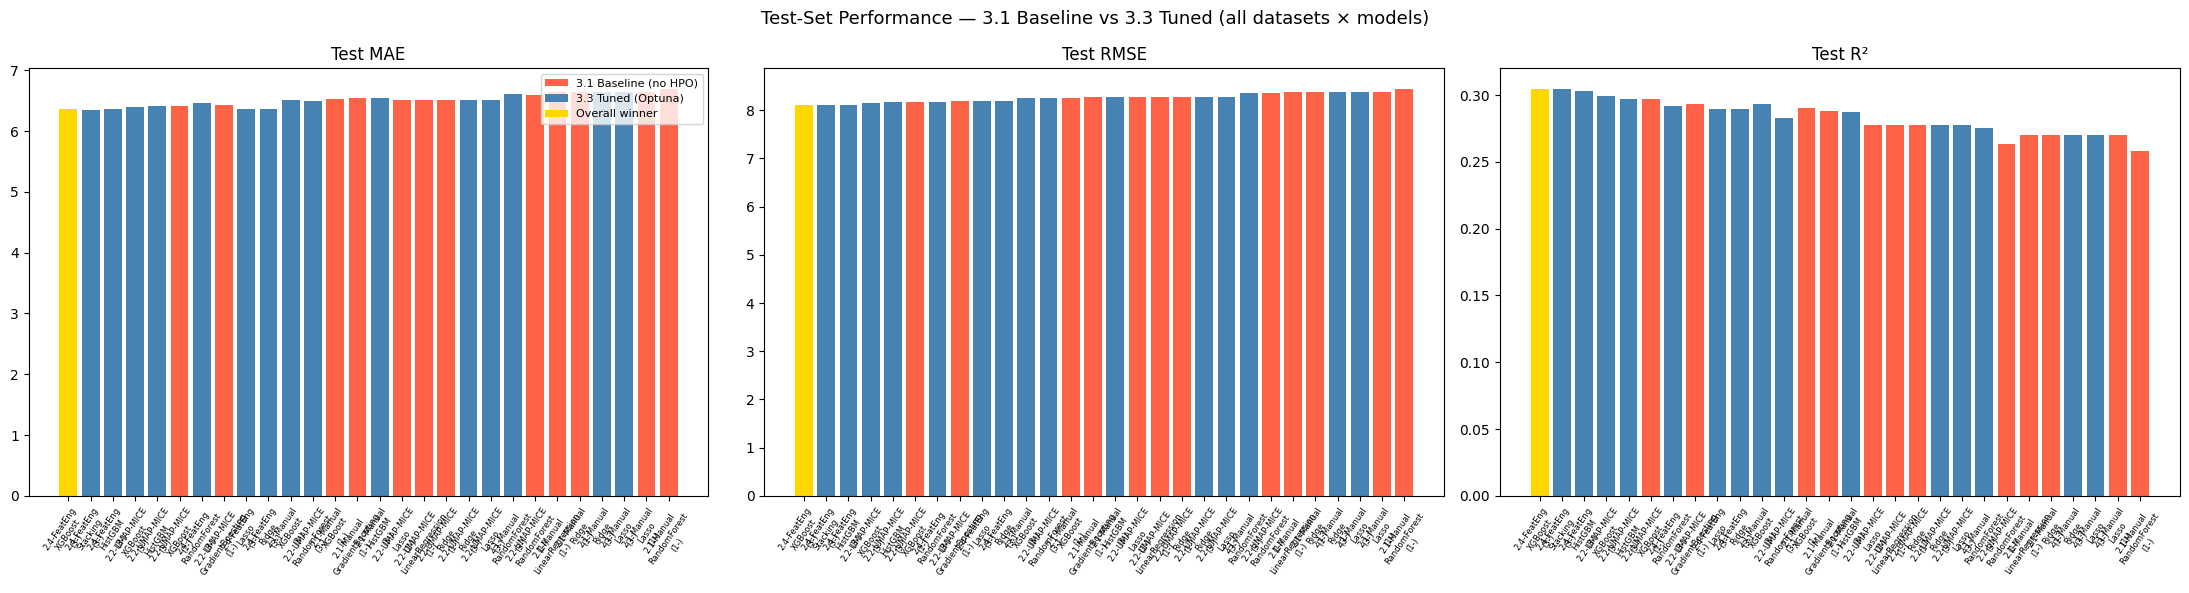

In [17]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Test-Set Performance — 3.1 Baseline vs 3.3 Tuned (all datasets × models)', fontsize=13)

all_rows = combined_df.to_dicts()
labels   = [f'{r["Dataset"]}\n{r["Model"]}\n({r["Source"][2:4]})' for r in all_rows]
colors   = ['tomato' if r['Source'] == '3.1-Baseline' else 'steelblue' for r in all_rows]
colors[0] = 'gold'   # mark overall winner

for ax, metric in zip(axes, ['Test MAE', 'Test RMSE', 'Test R²']):
    values = [r[metric] for r in all_rows]
    ax.bar(labels, values, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=55, labelsize=6)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',    label='3.1 Baseline (no HPO)'),
    Patch(facecolor='steelblue', label='3.3 Tuned (Optuna)'),
    Patch(facecolor='gold',      label='Overall winner'),
]
axes[0].legend(handles=legend_elements, fontsize=8)
plt.tight_layout()
plt.show()

## 8. CV vs Test RMSE Gap — Overfitting Diagnostic

A large positive gap (Test RMSE >> CV RMSE) signals overfitting.  
A negative gap (Test RMSE < CV RMSE) may indicate the test set is slightly easier than training.

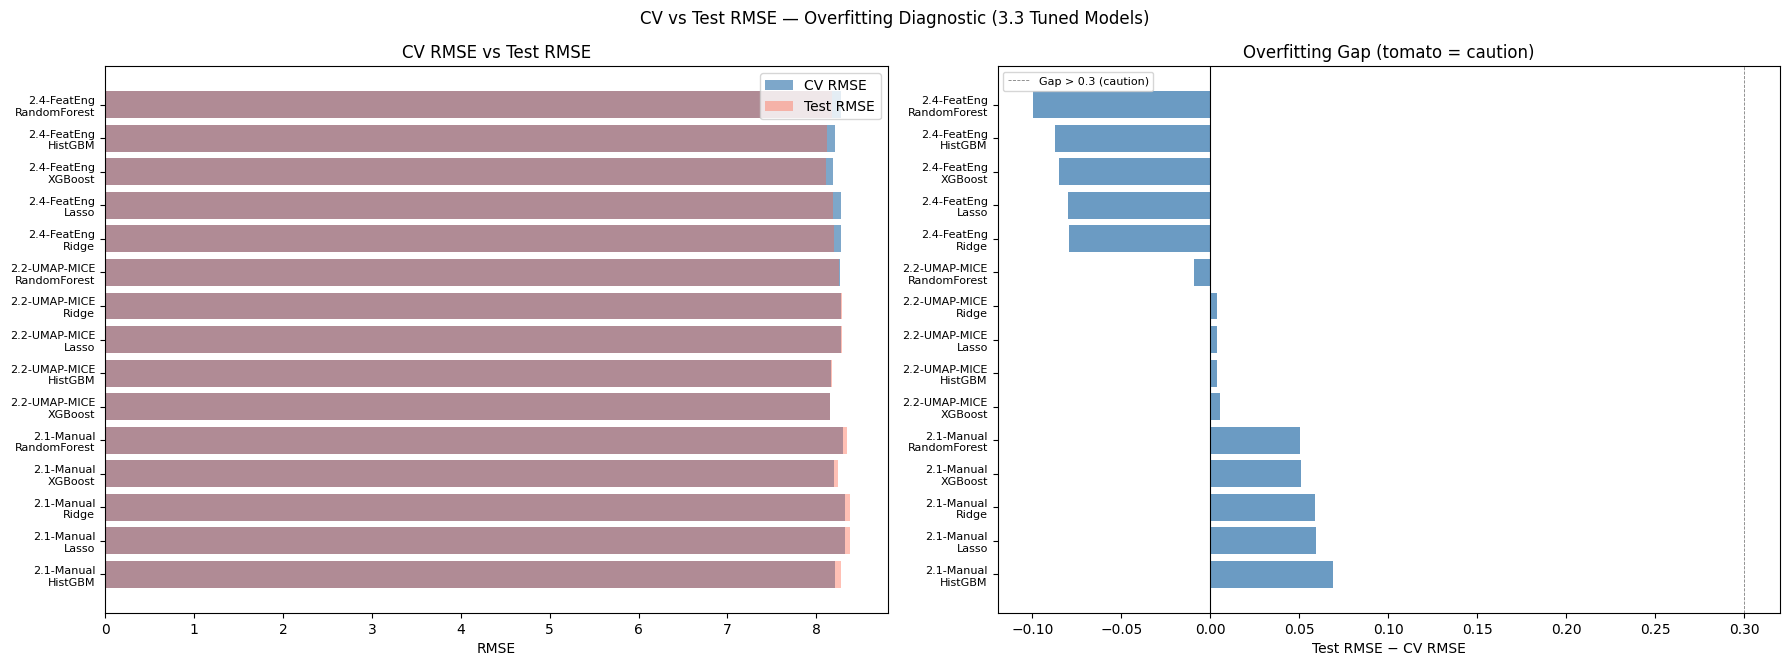


Models with gap > 0.3 (potential overfit):
  None — all models generalise well.


In [18]:
import math

gap_rows = []
for ds_label, models_dict in all_results_33.items():
    for mdl_name, res in models_dict.items():
        cv_r   = res['cv_rmse']
        test_r = res['test_rmse']
        if math.isnan(cv_r):
            continue
        gap_rows.append({
            'Label':     f'{ds_label}\n{mdl_name}',
            'CV RMSE':   cv_r,
            'Test RMSE': test_r,
            'Gap':       test_r - cv_r,
        })

gap_df = sorted(gap_rows, key=lambda x: x['Gap'], reverse=True)

labels_g     = [r['Label']    for r in gap_df]
cv_vals      = [r['CV RMSE']  for r in gap_df]
test_vals    = [r['Test RMSE']for r in gap_df]
gaps         = [r['Gap']      for r in gap_df]
gap_colors   = ['tomato' if g > 0.3 else 'steelblue' for g in gaps]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, max(5, len(gap_df) * 0.45)))
fig.suptitle('CV vs Test RMSE — Overfitting Diagnostic (3.3 Tuned Models)', fontsize=12)

y_pos = range(len(gap_df))
ax1.barh(y_pos, cv_vals,   alpha=0.7, color='steelblue', label='CV RMSE')
ax1.barh(y_pos, test_vals, alpha=0.4, color='tomato',    label='Test RMSE')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels_g, fontsize=8)
ax1.set_xlabel('RMSE')
ax1.set_title('CV RMSE vs Test RMSE')
ax1.legend()

ax2.barh(y_pos, gaps, color=gap_colors, alpha=0.8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.axvline(0.3, color='grey', linewidth=0.6, linestyle='--', label='Gap > 0.3 (caution)')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels_g, fontsize=8)
ax2.set_xlabel('Test RMSE − CV RMSE')
ax2.set_title('Overfitting Gap (tomato = caution)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nModels with gap > 0.3 (potential overfit):')
flagged = [r for r in gap_df if r['Gap'] > 0.3]
if flagged:
    for r in flagged:
        print(f"  {r['Label'].replace(chr(10), ' × '):<45s}  gap={r['Gap']:+.4f}")
else:
    print('  None — all models generalise well.')